In [19]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
#os.getcwd().split('CosmicDawnSynergies')[0] + 'CosmicDawnSynergies/src'
import CosmicDawnSynergies as cds


In [1]:
import hera_pspec as hp


In [107]:
import numpy as np
uvp = hp.UVPSpec()
uvp.read_hdf5("/home/sp2053/rds/hpc-work/CosmicDawnSynergies/data/observations_H1C_IDR3/Deltasq_Band_1_Field_D_idr3.h5")

band_key = uvp.get_all_keys()[0]
spw_index = uvp.spw_array[0]
# Get redshift (i.e. spherical window)
spw_frequencies = uvp.get_spw_ranges()[spw_index][:2] #:2 because we only want frequency range
z = uvp.cosmo.f2z(np.mean(spw_frequencies))
# Get wave number, data, error, and (k-space) window functions
kbins_data = uvp.get_kparas(spw_index)
kbins_model = uvp.get_kparas(spw_index)
dsq = uvp.get_data(band_key)[0].real.copy()
std = np.sqrt(uvp.get_cov(band_key)[0].diagonal().real.copy())
wfn = uvp.get_window_function(band_key)

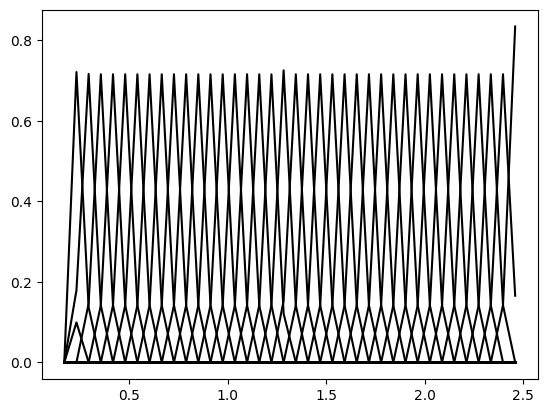

In [109]:
ks = slice(2, None)
plt.plot(kbins_data[ks], wfn[0, ks, ks], c='k', lw=1.5)


shapes: (16,), (16,), (16,)
shapes: (19,), (19,), (19,)
shapes: (23,), (23,), (23,)
shapes: (27,), (27,), (27,)
shapes: (18,), (18,), (18,)
shapes: (34,), (34,), (34,)
shapes: (34,), (34,), (34,)
shapes: (45,), (45,), (45,)


Text(0, 0.5, '$\\Delta^2(k)$')

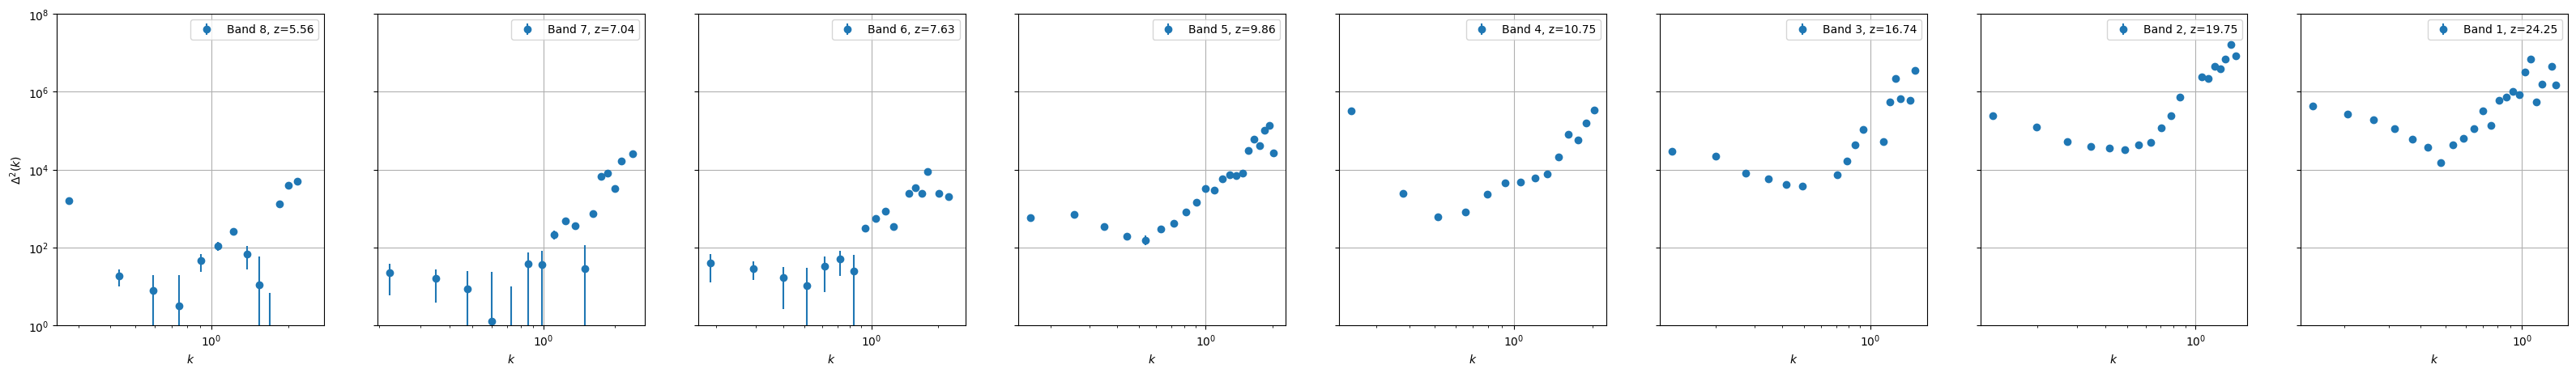

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8, figsize=(5*8, 5), sharey=True)
for i, ax in zip(range(8, 0, -1), axes):
    x = hp.UVPSpec()
    fn = f"/home/sp2053/rds/hpc-work/CosmicDawnSynergies/data/observations_H6C_IDR2/Deltasq_Band_{i}.h5"
    x.read_hdf5(fn)

    key = x.get_all_keys()[0]
    spw_index = x.spw_array[0]
    # Get the delta^2
    x.get_data(key)

    # Get the (diagonal) covariance
    std = np.sqrt(x.get_stats('P_SN', key).real[0])
    x.convert_to_deltasq()
    dsq = x.data_array[0].real[0,:,0]

    spw_frequencies = x.get_spw_ranges()[spw_index][:2]
    z = uvp.cosmo.f2z(np.mean(spw_frequencies))

    k_para = x.get_kparas(spw_index)
    k_perp = x.get_kperps(spw_index)
    k_mag = np.sqrt(k_perp**2 + k_para**2)
    mask = dsq+std < 1e10 #Pk>-1e10 
    
    ax.errorbar(k_mag[mask], dsq[mask], yerr=std[mask], fmt='o', label=f"Band {i}, z={z:.2f}")
    ax.legend()
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e0, 1e8)
    ax.set_xlabel('$k$')
    ax.grid()

axes[0].set_ylabel('$\Delta^2(k)$')


    





In [13]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from CosmicDawnSynergies import likelihood_hera as likehera

#selection = [{"1": {"D": {"kstart":0.36}}}, {"2": {"C": {"kstart":0.34}}}]
datapath = "/home/sp2053/rds/hpc-work/CosmicDawnSynergies/data/observations_H6C_IDR2/Deltasq_Band_1.h5"

data = likehera.extract_data(datapath=datapath,
    band=0,
    field=0,
    kstart=0,
    kstart_modulo=False,
    decimation_factor=None,
    set_negative_to_zero=True
    )

dpath = [f"/home/sp2053/rds/hpc-work/CosmicDawnSynergies/data/observations_H6C_IDR2/Deltasq_Band_{i}.h5" for i in range(7,0,-1)]
selections = len(range(8,0,-1))*[None,]
like_hera_h6c = likehera.likelihood(datapath=dpath, selections=len(range(8,0,-1))*[None,], zero_fill=1e-50,
                decimation_factor=2, set_negative_to_zero=True, theory_err=0.2, kstart_modulo=True,
                return_individual_loglikes=False, debug=False,
                emupath='data/trained_emulators_poweremu/dsq_emu_n500_l100100100100_t1e-05_o0.pkl',
                output_names = {"logL_HERA": r"\log L_\mathrm{HERA}"}
                 )



#H1C IDR3

selection = [{"1": {"D": {"kstart":0.36}}}, {"2": {"C": {"kstart":0.34}}}]
dpath = [
    'data/observations_H1C_IDR3/Deltasq_Band_1_Field_D_idr3.h5',
    'data/observations_H1C_IDR3/Deltasq_Band_2_Field_C_idr3.h5']
like_hera_h1c = likehera.likelihood(
    datapath=dpath,
    decimation_factor=2,
    selections=selection,
    return_individual_loglikes=False, #Can only use false with this new likelihood module approach
    emupath='data/trained_emulators_poweremu/dsq_emu_n500_l100100100100_t1e-05_o0.pkl',
    output_names = {"logL_HERA": r"\log L_\mathrm{HERA}"}
)

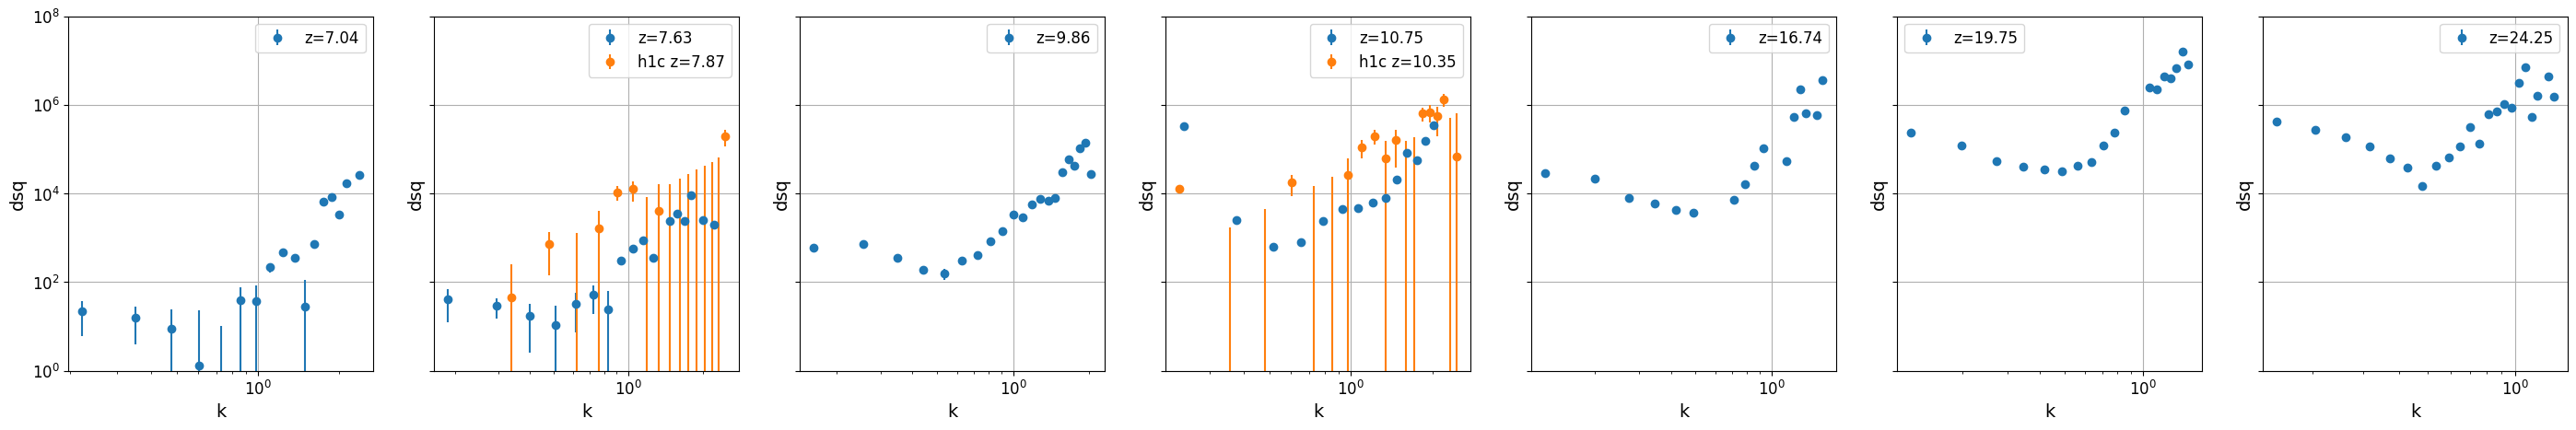

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 8-1, figsize=(5*(8-1), 5), sharey=True)
for i,(key1,ax) in enumerate(zip(like_hera_h6c.data.keys(),axes)):
    key2 = "0"
    dsq = like_hera_h6c.data[key1][key2]["dsq"]
    std = like_hera_h6c.data[key1][key2]["std"]
    k = like_hera_h6c.data[key1][key2]["k_data"]
    mask = dsq+std < 1e10
    
    dsq = dsq[mask]
    std = std[mask]
    k = k[mask]

    z = like_hera_h6c.data[key1][key2]["z"]
    ax.errorbar(k, dsq, yerr=std, fmt='o', label=f"z={z:.2f}")
    
    ax.set_xlabel('k')
    ax.set_ylabel("dsq")
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_ylim(1e0, 1e8)
    ax.grid()

    if i==2-1:
        data = like_hera_h1c.data["2"]["C"]
        dsq = data["dsq"]
        std = data["std"]
        k = data["k_data"]
        mask = dsq+std < 1e10

        dsq = dsq[mask]
        std = std[mask]
        k = k[mask]

        z = data["z"]
        ax.errorbar(k, dsq, yerr=std, fmt='o', label=f"h1c z={z:.2f}")

    if i == 4-1:
        data = like_hera_h1c.data["1"]["D"]
        dsq = data["dsq"]
        std = data["std"]
        k = data["k_data"]
        mask = dsq+std < 1e10

        dsq = dsq[mask]
        std = std[mask]
        k = k[mask]

        z = data["z"]
        ax.errorbar(k, dsq, yerr=std, fmt='o', label=f"h1c z={z:.2f}")


    ax.legend()

In [10]:
like_hera_h1c.data["2"]["C"]#.keys()

{'z': 7.868874933073171,
 'k_model': array([0.12405163, 0.19493828, 0.26582493, 0.33671158, 0.40759823,
        0.47848487, 0.54937152, 0.62025817, 0.69114482, 0.76203146,
        0.83291811, 0.90380476, 0.97469141, 1.04557806, 1.1164647 ,
        1.18735135, 1.258238  , 1.32912465, 1.4000113 , 1.47089794,
        1.54178459, 1.61267124, 1.68355789, 1.75444454, 1.82533118,
        1.89621783, 1.96710448, 2.03799113, 2.10887777, 2.17976442,
        2.25065107, 2.32153772, 2.39242437, 2.46331101]),
 'dsq': array([4.41866693e+01, 7.35995026e+02, 0.00000000e+00, 1.63595806e+03,
        1.05695726e+04, 1.25159208e+04, 0.00000000e+00, 4.08301698e+03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.94268931e+05]),
 'std': array([  206.43416089,   594.65147391,  1304.56099559,  2340.50649599,
         3868.2202112 ,  5957.71742385,  8473.08615921, 11855.34877244,
        16093.86829374, 21177.6717952 , 27134.3813